LLM MODEL

installs

In [ ]:
!pip install -q bitsandbytes==0.45.2 --no-deps
!pip install -q transformers==4.41.2 --no-deps
!pip install -q peft==0.10.0 --no-deps
!pip install -q accelerate==0.29.3 --no-deps
!pip install -q trl==0.8.6 --no-deps
!pip install -q tokenizers==0.19.1 --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 MB 36.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.2/245.2 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 40.5 MB/s eta 0:00:00


imports

In [ ]:
import torch
import transformers
import bitsandbytes as bnb
from trl import SFTTrainer

print("Torch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.is_available())
print("Transformers:", transformers.__version__)

Torch: 2.6.0+cu124
CUDA: 12.4
GPU: True
Transformers: 4.41.2


In [ ]:
!pip install -q pyarrow==15.0.2 --no-deps
!pip install -q pyarrow-hotfix --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.3/38.3 MB 73.4 MB/s eta 0:00:00


In [ ]:
!pip install -q numpy==1.26.4 --no-deps

!pip install -q pyarrow==15.0.2
!pip install -q pyarrow-hotfix

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 129.4 MB/s eta 0:00:00


In [ ]:

import pandas as pd

load dataset

In [ ]:
## df_product = pd.read_csv("../data/df_product_for_llm.csv") for local notebook
# for colab
df_product = pd.read_csv("df_product_for_llm.csv")

df_product.head()
df_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       83 non-null     object 
 1   name                     83 non-null     object 
 2   brand                    83 non-null     object 
 3   manufacturer             83 non-null     object 
 4   macro_category           83 non-null     object 
 5   imageURL                 83 non-null     object 
 6   all_reviews_text         83 non-null     object 
 7   avg_sentiment_intensity  83 non-null     float64
 8   num_reviews              83 non-null     int64  
 9   rank_in_category         83 non-null     float64
 10  rank_worst_in_category   83 non-null     float64
dtypes: float64(3), int64(1), object(7)
memory usage: 7.3+ KB


LLM MODEL - MISTRAL 7B

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

model_id = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto"
)

model.config.use_cache = False
model.gradient_checkpointing_enable()

print("Model loaded")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.54G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Model loaded


BASELINE - PRODUCT REVIEW

In [ ]:
# choosing one product to use as baseline

df_product.sort_values("rank_in_category").head(10)[
    ["name", "avg_sentiment_intensity", "rank_in_category"]
]

,name,avg_sentiment_intensity,rank_in_category
81,Cat Litter Box Covered Tray Kitten Extra Large...,0.955088,1.0
78,Amazon Echo (2nd Generation) Smart Assistant O...,0.961148,1.0
23,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,0.833151,1.0
0,All-New Kindle Oasis E-reader - 7 High-Resolut...,0.821546,2.0
2,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,0.862554,2.0
6,AmazonBasics Single-Door Folding Metal Dog Cra...,0.923199,2.0
40,AmazonBasics Nespresso Pod Storage Drawer - 50...,0.869024,3.0
4,Amazon Kindle Paperwhite - eBook reader - 4 GB...,0.817425,3.0
68,Echo Dot (Previous generation),0.861824,3.0
36,"Kindle Voyage E-reader, 6 High-Resolution Disp...",0.792110,4.0


aux functions - scale reviews and limit characters



In [ ]:
def scale_score(sentiment):
    # scale from [-1,1] to [0,10]
    return (sentiment + 1) * 5

def truncate_reviews(text, max_chars=2000):
    return text[:max_chars]

In [ ]:
# selected product

row = df_product.iloc[74]

PROMPT

In [ ]:
#limit to text review
def truncate_reviews(text, max_chars=4000):
    return text[:max_chars]

In [ ]:
def build_prompt(row):
    reviews_text = truncate_reviews(row['all_reviews_text'])
    return f"""
You are a professional tech reviewer.
Use the following user review excerpts:
{reviews_text}

Write a detailed product review article with this structure:

Product name: {row['name']}

User score (0-10 scale): {scale_score(row['avg_sentiment_intensity']):.1f}
Rank in its category: {int(row['rank_in_category'])} (1 = best position)

Brand: {row['brand']}
Category: {row['macro_category']}

Headline

Product summary

Key features

Pros

Cons

Instructions:
- Headline must be one sentence.
- Product summary: 2–3 sentences.
- Key features: 2–5 bullet points explaining why they matter.
- Pros: 2–3 bullet points.
- Cons: 2–3 bullet points.
- Emphasize complaints more if score is low.
"""

In [ ]:
def generate_review(prompt, max_new_tokens=800, temperature=0.7, top_p=0.9):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            temperature=temperature,
            top_p=top_p,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    # limit tokens
    generated_tokens = outputs[0][inputs["input_ids"].shape[1]:]

    generated_text = tokenizer.decode(generated_tokens, skip_special_tokens=True)

    return generated_text.strip()

Generate baseline

In [ ]:
prompt = build_prompt(row)

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

output = model.generate(
    **inputs,
    max_new_tokens=600,
    temperature=0.7,
    top_p=0.9,
    repetition_penalty=1.1
)

generated_text = tokenizer.decode(output[0], skip_special_tokens=True)

print(generated_text)

/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:515: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/generation/configuration_utils.py:520: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.9` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



You are a professional tech reviewer.
Use the following user review excerpts:
Great Gift for anyone. Very easy to setup. Coexist with all IOT Devices. Alexa is AWESOME! Super excited to give this as a gift. It's super convenient that Best Buy has Echo products in store instead of having to purchase from Amazon. We bought this for mother in law, buying another for me. Well designed, good sound, has everything Alexa has plus the HD video. Always ready with answers with associated video or text if applicable. Can show movie trailers, can also watch Amazon video. Excellent on-demand security video with Amazon compatible cameras. Voice activated message and/or video calls to Amazon Show owners or Alexa App holders. Highly recommended. I have one Alexa and three Echo dots and having Echo Show now is awesome! Omg I love my amazon show it is sooo cool and does a lot of cool stuff Great looking design. Amazon Echo Show was easy to set up and use. The product is very entertaining and useful. Wo

Printed review


**Product name:** Amazon Echo Show Alexa-enabled Bluetooth Speaker with 7" Screen

**User score (0-10 scale):** 8.9
**Rank in its category:** 4

**Headline:**
Amazon Echo Show: A Sleek and Versatile Smart Speaker with a 7-inch Touchscreen

**Product summary:**
The Amazon Echo Show is a high-performing smart speaker featuring Alexa voice control and a vibrant 7-inch touchscreen display. Its sleek design and impressive functionality make it an excellent addition to any modern home.

**Key features:**

* **Alexa voice control:** Hands-free access to millions of songs, radio stations, audiobooks, and other content.
* **HD touchscreen display:** Enhances visual experience by providing real-time information, video calls, and multimedia content.
* **Smart home integration:** Control compatible devices such as lights, thermostats, and cameras using voice commands.
* **Entertainment system:** Stream movies, TV shows, music, and more through popular apps like Netflix, YouTube, and Pandora.

**Pros:**

* **Easy setup:** Quick and straightforward process using the Alexa app.
* **Versatile usage:** Acts as a home security camera, digital photo frame, and entertainment center.
* **Excellent sound quality:** Rich, clear audio for music and voice recognition.

**Cons:**

* **Limited compatibility:** Not all third-party apps are supported.
* **Occasional connectivity issues:** Users report occasional difficulties connecting to Wi-Fi networks or other devices.

**Product review:**

The Amazon Echo Show is a game-changer in the realm of smart speakers. With its sleek design and impressive functionality, it sets itself apart from competitors. The 7-inch touchscreen display adds a whole new dimension to the user experience, making it an excellent choice for those seeking a more interactive and engaging smart speaker.

One of the most significant advantages of the Amazon Echo Show is its seamless integration with Alexa voice control. Users can effortlessly access millions of songs, radio stations, audiobooks, and other content hands-free. Additionally, the HD touchscreen display enhances the visual experience by providing real-time information, video calls, and multimedia content.

Evaluation

* The model correctly follows the requested structural format (Headline, Summary, Features, Pros, Cons).
* The overall tone is consistent with the high user score (8.9/10), maintaining a predominantly positive evaluation.
* The text is coherent, fluent, and professionally written.
* However, the model introduces features and platform references that are not explicitly mentioned in the provided review excerpts, indicating mild hallucination.
* It underutilizes several concrete and product-specific details present in the user reviews.
* The output reflects strong stylistic compliance but limited strict grounding in the source text.
* Overall, the baseline performs well structurally but requires stronger source adherence, potentially through prompt refinement or fine-tuning.


PROMPT TUNING

In [ ]:
def build_prompt_strict(row):
    reviews_text = truncate_reviews(row["all_reviews_text"], max_chars=4000)

    return f"""
You are a professional tech reviewer.

You must write the review using ONLY the information explicitly contained in the user review excerpts below.
Do NOT add features, specifications, platform names, or capabilities that are not directly mentioned.
If something is not clearly stated in the excerpts, do not invent it.
Do not use outside knowledge about the product.

User review excerpts:
{reviews_text}

Write a structured product review with the following exact sections and nothing else:

Product name: {row['name']}
User score (0-10 scale): {scale_score(row['avg_sentiment_intensity']):.1f}
Rank in its category: {int(row['rank_in_category'])} (1 = best position)
Brand: {row['brand']}
Category: {row['macro_category']}

Headline
- One single sentence summarizing the most common opinion in the reviews.

Product summary
- 2–3 sentences summarizing the overall user perception.

Key features
- 2–5 bullet points.
- Each feature must be clearly supported by information from the excerpts.
- Explain briefly why each feature matters to users.

Pros
- 2–3 bullet points.
- Must reflect explicitly positive comments found in the excerpts.

Cons
- 2–3 bullet points.
- Must reflect explicitly negative comments found in the excerpts.
- If the score is high, keep cons balanced but realistic.

Do not add any extra sections.
Do not add a concluding paragraph.
Return only the structured review.
"""

In [ ]:
# more conservative values

prompt = build_prompt_strict(row)

review = generate_review(
    prompt,
    max_new_tokens=800,
    temperature=0.5,
    top_p=0.8
)

print(review)


Product name: Amazon Echo Show
User score (0-10 scale): 8.9
Rank in its category: 4
Brand: Amazon
Category: smart speakers

Headline
Great gift option with Alexa and a 7" screen.

Product summary
The Amazon Echo Show is a popular smart speaker with Alexa voice control and a 7" screen. Users appreciate its ease of setup and compatibility with various IoT devices. Alexa's capabilities, such as voice-activated video calls and on-demand security video, are highly regarded.

Key features
- Alexa voice control with a 7" touchscreen
- Easy setup and compatibility with various IoT devices
- Alexa capabilities, such as voice-activated video calls, on-demand security video, and movie trailers/Amazon video
- High-quality sound

Pros
- Great gift option
- Easy to set up and use
- Alexa's capabilities are entertaining and useful
- Good sound quality

Cons
- Some users find that the device fades away from their life after a few weeks
- No Bluetooth speaker capability for the speakers

Note: The use

Strict review

Product name: Amazon Echo Show
User score (0-10 scale): 8.9
Rank in its category: 4
Brand: Amazon
Category: smart speakers

Headline
Amazon Echo Show is a highly recommended smart speaker with a 7" screen, easy setup, and Alexa's awesome features.

Product summary
The Amazon Echo Show is a popular choice among users for its ease of setup, great design, and Alexa's capabilities. It's a great gift option and can coexist with all IoT devices.

Key features
- 7" screen for video and visual content
- Easy setup with Best Buy's in-store availability
- Alexa's capabilities including voice commands, answers, and entertainment

Pros
- Well-designed with good sound quality
- Alexa's voice activated features are highly convenient
- Can show movie trailers, Amazon videos, and security camera feeds

Cons
- Some users find the speakers could have better Bluetooth capabilities
- The device may fade from users' lives after some time

Overall, the Amazon Echo Show is a highly recommended smart speaker with its easy setup, great design, and Alexa's awesome features. Users love the convenience of voice commands and the ability to watch videos and trailers. However, some users suggest improving the Bluetooth capabilities and note that the device may not be as engaging after some time.

Evaluation

* The prompt-hardened version shows a clear improvement over the initial baseline, particularly in reducing hallucinations and limiting unsupported feature additions.
* The model demonstrates stronger grounding in the provided review excerpts, incorporating more explicitly mentioned details and complaints.
* Alignment with user sentiment and ranking remains appropriate and consistent.
* However, the model still fails to fully respect structural constraints, adding an extra concluding paragraph despite explicit instructions not to do so.
* Although factual grounding has improved, the output remains somewhat generalized and does not fully leverage the richness of the original reviews.
* Overall, prompt refinement significantly enhanced source adherence and precision, but strict structural compliance and maximal detail extraction are not yet fully achieved.


FEW SHOT PROMPT

Choosing a high rank and low rank product

In [ ]:
df_product.sort_values("rank_in_category")[["name","rank_in_category","avg_sentiment_intensity"]].head(5)

,name,rank_in_category,avg_sentiment_intensity
81,Cat Litter Box Covered Tray Kitten Extra Large...,1.0,0.955088
78,Amazon Echo (2nd Generation) Smart Assistant O...,1.0,0.961148
23,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,1.0,0.833151
0,All-New Kindle Oasis E-reader - 7 High-Resolut...,2.0,0.821546
2,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,2.0,0.862554


In [ ]:
df_product.sort_values("rank_in_category", ascending=False)[["name","rank_in_category","avg_sentiment_intensity"]].head(5)

,name,rank_in_category,avg_sentiment_intensity
28,"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16...",39.0,-0.102934
26,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",38.0,0.014308
64,"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...",37.0,0.370030
18,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,36.0,0.457094
42,Brand New Amazon Kindle Fire 16gb 7 Ips Displa...,35.0,0.647632


In [ ]:
for idx in [81, 78, 28]:
    row = df_product.iloc[idx]
    print("INDEX:", idx)
    print("Name:", row["name"])
    print("Score:", scale_score(row["avg_sentiment_intensity"]))
    print("Rank:", row["rank_in_category"])
    print("Category:", row["macro_category"])
    print("-"*50)

INDEX: 81
Name: Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet
Score: 9.775440148243353
Rank: 1.0
Category: accessories and chargers
--------------------------------------------------
INDEX: 78
Name: Amazon Echo (2nd Generation) Smart Assistant Oak Finish Priority Shipping
Score: 9.805741449929164
Rank: 1.0
Category: smart speakers
--------------------------------------------------
INDEX: 28
Name: Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case
Score: 4.4853276664627435
Rank: 39.0
Category: tablets
--------------------------------------------------


In [ ]:
for idx in [81, 78, 28]:
    print("INDEX:", idx)
    print(df_product.iloc[idx]["all_reviews_text"][:1000])
    print("="*100)

INDEX: 81
I replaced my cat's x-large litter box to this smaller sized litter box... It's easy to clean and takes less kitty litter to fill it which I like Great price, good value!
INDEX: 78
I bought it for my grandson‚Äôs birthday... he loves it;) This was a gift for my mother and she absolutely loves this thing We have one in every room and it's nice that we can ask to play music in all the devices. She has a hard time understanding Spanish words and sometimes we've noticed that she replies from other rooms (not the one we are in). Overall a good buy to help you at home or office
INDEX: 28
I bought one of the first Macs in the 80s. I've had 'too many to count since then.' I am an early adopter, by nature. This has been true of Amazon's Kindle product as well having owned the First Generation Kindle, K2, K3 and now the K Touch. Love the reader. And I love this case as well. I hear all of these complaints that this leather case looks cheap or doesn't have a closure, or it's too slipper

In [ ]:
print(df_product.iloc[28]["all_reviews_text"])

I bought one of the first Macs in the 80s. I've had 'too many to count since then.' I am an early adopter, by nature. This has been true of Amazon's Kindle product as well having owned the First Generation Kindle, K2, K3 and now the K Touch. Love the reader. And I love this case as well. I hear all of these complaints that this leather case looks cheap or doesn't have a closure, or it's too slippery. PLEASE. I find it to be a PERFECT fit for the Kindle Touch. The unit snaps in a la DoDo Case -- which is such a great product for iPad. Very similar design only on a much smaller scale, obviously. The leather is not an issue for me. I do NOT find it to be too slippery at all unless, perhaps, your hands are covered in oil This is a first class cover for a first class e-reader. And NO. I do not work for Amazon. I'm just a HUGE Kindle fan. Overall it's a nice looking cover and does it's job well. It's simple, elegant and slick. When I say slick, I don't necessarily mean cleverly devised, I me

Few-shot prompt

In [ ]:
def build_few_shot_prompt(row):
    reviews_text = truncate_reviews(row["all_reviews_text"], max_chars=4000)

    few_shot_examples = """
You are a professional product reviewer.

You must write the review using ONLY the information explicitly contained in the provided review excerpts.
Do NOT add features, specifications, or capabilities that are not mentioned.
Do NOT add extra sections.
Follow the structure exactly.

----------------------------
Example 1

Product name: Cat Litter Box Covered Tray Kitten Extra Large Enclosed Hooded Hidden Toilet
User score (0-10 scale): 9.8
Rank in its category: 1 (1 = best position)
Brand: Not specified
Category: accessories and chargers

Headline
A compact and easy-to-clean litter box that offers great value and efficiency.

Product summary
Users appreciate this litter box for its practical size and ease of maintenance. Many reviewers highlight that it requires less litter while still meeting their needs, making it both convenient and cost-effective.

Key features
- Compact design: Replaces larger litter boxes while maintaining functionality.
- Easy to clean: Simplifies regular maintenance for pet owners.
- Efficient litter usage: Requires less litter to fill, reducing ongoing costs.
- Affordable pricing: Frequently described as a great value for the price.

Pros
- Easy to clean and maintain.
- Uses less litter compared to larger alternatives.
- Great price and strong value for money.

Cons
- Smaller size may not suit owners looking for extra-large capacity.

----------------------------
Example 2

Product name: Kindle Touch Leather Cover
User score (0-10 scale): 4.5
Rank in its category: 39 (1 = best position)
Brand: Amazon
Category: tablets

Headline
A lightweight and secure Kindle cover with appealing design, but questionable durability and pricing.

Product summary
Users appreciate the lightweight construction and secure fit, particularly the rubberized locking mechanism that holds the device firmly in place. However, recurring concerns about thin leather, lack of closure mechanism, and perceived high price significantly affect overall satisfaction.

Key features
- Secure locking system: Snaps into a rubberized groove without corner straps.
- Lightweight construction: Noticeably lighter than previous generations.
- Genuine leather exterior: Polished appearance.
- Minimalist design: No elastic bands obstructing the screen.

Pros
- Holds the device securely.
- Lightweight and unobtrusive.
- Clean and stylish design.

Cons
- Thin and potentially flimsy leather.
- Slippery surface that may reduce grip.
- No closure mechanism.
- Frequently described as overpriced.

----------------------------
Now write the review for the following product:

Product name: {row['name']}
User score (0-10 scale): {scale_score(row['avg_sentiment_intensity']):.1f}
Rank in its category: {int(row['rank_in_category'])} (1 = best position)
Brand: {row['brand']}
Category: {row['macro_category']}

User review excerpts:
{reviews_text}

Follow the exact same structure as the examples.
Do not add any extra section.
Return only the structured review.
"""

    return few_shot_examples

Evaluate

In [ ]:
row = df_product.iloc[78]

prompt = build_few_shot_prompt(row)

review = generate_review(
    prompt,
    max_new_tokens=800,
    temperature=0.4,   # más control
    top_p=0.85
)

print(review)


----------------------------
Product name: Samsung Galaxy S21 Ultra
User score (0-10 scale): 8.5
Rank in its category: 2 (1 = best position)
Brand: Samsung
Category: smartphones

Headline
An impressive flagship smartphone with a stunning camera system and long-lasting battery life.

Product summary
Users are consistently impressed with the Samsung Galaxy S21 Ultra's advanced camera capabilities and the long-lasting battery life. Many reviewers note that the camera system outperforms competitors, while the battery life exceeds their expectations.

Key features
- Advanced camera system: Captures high-quality images and videos.
- Long-lasting battery life: Supports extended usage without frequent charging.
- Sleek design: Attractive and modern appearance.
- Powerful performance: Delivers smooth multitasking and gaming experiences.

Pros
- High-quality camera system.
- Long-lasting battery life.
- Sleek and modern design.
- Powerful performance.

Cons
- Expensive price point.

-----------

Output



Headline
A versatile and reliable {row['product_type']} with a sleek design and impressive battery life.

Product summary
Users praise the {row['product_type']} for its impressive battery life, allowing for extended use without frequent recharging. The sleek and modern design is also frequently mentioned as a significant selling point.

Key features
- Impressive battery life: Lasts longer than competitors.
- Sleek and modern design: Attractive appearance.

Pros
- Long battery life.
- Modern and stylish design.

Cons
- No specific cons mentioned in the provided excerpts.


INTERPRETATION

The few-shot experiment did not produce the expected improvements: despite providing structured examples, the model reverted to a generic template, ignored specific review excerpts, and even introduced placeholder artifacts, indicating weak conditioning on the demonstrations. This suggests that long few-shot prompts are insufficient to reliably enforce structural rigidity and strict source grounding in this setup. Given these limitations, a supervised fine-tuning approach with QLoRA is now justified to achieve consistent formatting, stronger excerpt adherence, and more controlled generation behavior.


QLORA

Creating dataset for training

In [ ]:
# Select 10 varied products
selected_indices = [81, 78, 28, 10, 15, 22, 35, 40, 55, 60]

training_data = []

for idx in selected_indices:
    row = df_product.iloc[idx]
    prompt = build_prompt_strict(row)

    review = generate_review(
        prompt,
        max_new_tokens=700,
        temperature=0.4,
        top_p=0.85
    )

    training_data.append({
        "instruction": prompt,
        "response": review
    })

len(training_data)

10

In [ ]:
# export to edit manually
import pandas as pd

df_train = pd.DataFrame(training_data)

df_train.to_csv("qlora_training_raw.csv", index=False)

df_train.head()

In [ ]:
# import edited csv
import pandas as pd

df_clean = pd.read_csv("qlora_training_clean.csv")

df_clean.head()

,instruction,response
0,\nYou are a professional tech reviewer.\n\nYou...,Product review:\n\nHeadline:\nSatisfied cat ow...
1,\nYou are a professional tech reviewer.\n\nYou...,Product name: Amazon Echo (2nd Generation) Sma...
2,\nYou are a professional tech reviewer.\n\nYou...,Headline:\nThis cover is a perfect fit for the...
3,\nYou are a professional tech reviewer.\n\nYou...,Product name: AmazonBasics Nylon CD/DVD Binder...
4,\nYou are a professional tech reviewer.\n\nYou...,"Product name: Kindle Keyboard,\n\nHeadline:\nT..."


Format dataset

In [ ]:
from datasets import Dataset

formatted_data = []

for _, row in df_clean.iterrows():
    formatted_text = f"""### Instruction:
{row['instruction']}

### Response:
{row['response']}"""

    formatted_data.append({"text": formatted_text})

dataset = Dataset.from_list(formatted_data)

len(dataset)

40

Config

In [ ]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

In [ ]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 41,943,040 || all params: 7,283,675,136 || trainable%: 0.5758499550960753


Training

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qlora-review-model",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    num_train_epochs=5,
    learning_rate=2e-4,
    logging_steps=1,
    save_strategy="no",
    fp16=True,
    report_to="none"
)

tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    dataset_text_field="text",
    max_seq_length=2048,
    tokenizer=tokenizer,
    args=training_args
)

trainer.train()

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
1,1.991800
2,1.748600
3,1.436400
4,1.135600
5,1.079500
6,1.279300
7,0.846300
8,0.644000
9,1.212300
10,0.764500


TrainOutput(global_step=10, training_loss=1.2138372242450715, metrics={'train_runtime': 237.4531, 'train_samples_per_second': 0.211, 'train_steps_per_second': 0.042, 'total_flos': 2283282583486464.0, 'train_loss': 1.2138372242450715, 'epoch': 4.0})

In [ ]:
model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralSdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
              )
              (k_proj): lora.Linear4bit(
                (base_layer):

Manual evaluation

In [ ]:
row = df_product.iloc[78]

prompt = build_prompt_strict(row)

review = generate_review(
    prompt,
    max_new_tokens=700,
    temperature=0.4,
    top_p=0.85
)

print(review)

Output



Headline
Grandparents love the Amazon Echo for easy music control and multi-room compatibility.

Product summary
The Amazon Echo (2nd Generation) Smart Assistant Oak Finish Priority Shipping is a popular choice among grandparents for its ease of use in playing music and its multi-room compatibility.

Key features
- Easy music control: Users can ask their Echo device to play music, making it convenient for grandparents who may have difficulty using traditional music players.
- Multi-room compatibility: Grandparents can place Echo devices in multiple rooms and ask to play music on all of them, providing a more immersive listening experience.

Pros
- Easy music control: "She has a hard time understanding Spanish words and sometimes we've noticed that she replies from other rooms (not the one we are in). Overall a good buy to help you at home or office"
- Multi-room compatibility: "We have one in every room and it's nice that we can ask to play music in all the devices."

Cons
- Spanish language understanding may not be perfect: "I have noticed that sometimes she doesn't understand Spanish words correctly."
- May respond from wrong room: "Sometimes she replies from other rooms (not the one we are in)."


INTERPRETATION

While QLoRA improved structural compliance and reduced hallucinations, it did not significantly enhance semantic discrimination between positive and negative user feedback, likely due to the small size and limited diversity of the fine-tuning datase

- Doing another pass to the csv dataset
- Adding "Do not quote the reviews directly. Summarize instead of copying sentences verbatim." to the prompt


DATASET FOR TRAINING V2

Goal:

*   Produce dataset with more products to train and keeping others as holdouts (to ensure model is not memorizing)
*   Force less quoting
*   Use less examples
*   Force correct separation pros and cons   
*   Adapt format to mistral preferences







Getting a stratified (rank-wise) sample of 40 products this time

In [ ]:
# a stratified split based on sentiment intensity was performed
# to ensure balanced representation of positive, neutral, and negative products

N_TRAIN = 40
N_BUCKETS = 3

# three groups per score
df_product["score_bucket"] = pd.qcut(
    df_product["avg_sentiment_intensity"],
    q=N_BUCKETS,
    labels=["low", "mid", "high"]
)

# Number per bucket
per_bucket = N_TRAIN // N_BUCKETS
remainder = N_TRAIN % N_BUCKETS

train_indices = []

for i, bucket in enumerate(["low", "mid", "high"]):
    bucket_df = df_product[df_product["score_bucket"] == bucket]

    # distribute remainder
    n_samples = per_bucket + (1 if i < remainder else 0)

    sampled = bucket_df.sample(n=n_samples, random_state=42)
    train_indices.extend(sampled.index.tolist())

train_df = df_product.loc[train_indices].copy()

print("Training size:", len(train_df))

Training size: 40


PROMPT v2 (one shot)

In [ ]:
# using a product with more mixed opinions to help the model differentiate positive and negative, pros and cons.

def prompt_v2(row):

    example = """
Example:

Headline
A lightweight and stylish Kindle cover with secure fit but debatable price.

Product summary
Users appreciate the secure fit and elegant appearance of this Kindle leather cover. It is lightweight and unobtrusive, though some buyers question whether the price reflects the material quality.

Key features
- Secure locking system: Holds the Kindle firmly without straps, improving usability.
- Lightweight construction: Adds minimal bulk while protecting the device.
- Genuine leather finish: Provides a refined look, though thinner than previous versions.

Pros
- Secure and snug device fit
- Lightweight and easy to handle
- Elegant and minimalist design

Cons
- Leather feels thin compared to previous models
- No closure mechanism
- Considered expensive by some users

Final assessment
Overall, this cover offers a secure and stylish solution for Kindle users, though its price and thinner leather may not appeal to everyone.
"""

    instruction = f"""
You are a professional product reviewer.

Use ONLY the information provided in the user review excerpts.
Do NOT add external knowledge.
Do NOT quote the reviews directly. Summarize instead of copying sentences verbatim.
Pros must contain only positive aspects.
Cons must contain only negative aspects.
Follow exactly this structure:

Headline
Product summary
Key features (2–5 bullet points)
Pros (2–3 bullet points)
Cons (2–3 bullet points)
Final assessment (1 short paragraph, maximum 3 sentences)

The final assessment must be concise and must not introduce new information.


User review excerpts:
{truncate_reviews(row['all_reviews_text'])}

Now write the review.
"""

    return example + "\n\n" + instruction




Using model base to generate target reviews

In [ ]:
training_raw = []

for idx, row in train_df.iterrows():
    prompt = prompt_v2(row)

    review = generate_review(
        prompt,
        max_new_tokens=700,
        temperature=0.3,
        top_p=0.85
    )

    training_raw.append({
        "instruction": prompt,
        "response": review
    })

training_raw_df = pd.DataFrame(training_raw)
training_raw_df.to_csv("qlora_training_raw_40.csv", index=False)

print("Saved qlora_training_raw_40.csv")

Saved qlora_training_raw_40.csv


In [ ]:
# automatic cleaning and format application

import re

df_raw = pd.read_csv("qlora_training_raw_40.csv")

negative_keywords = [
    "not", "no ", "problem", "expensive", "slippery",
    "flimsy", "hard", "lack", "doesn't", "doesnt",
    "issue", "concern", "overpriced",
    "poor", "weak", "difficult"
]

def clean_response(text):
    if pd.isna(text):
        return text

    # Remove quotes
    text = re.sub(r'\".*?\"', '', text)
    text = text.replace('"', '').replace("'", "")

    # Keep only required sections
    pattern = r"(Headline.*?Cons\s*\n(?:- .+\n?)*)"
    match = re.search(pattern, text, re.DOTALL)

    if match:
        text = match.group(1).strip()

    lines = text.split("\n")
    cleaned = []
    current_section = None
    pros = []
    cons = []

    for line in lines:
        stripped = line.strip()

        if stripped.startswith("Pros"):
            current_section = "pros"
            cleaned.append("Pros")
            continue
        elif stripped.startswith("Cons"):
            current_section = "cons"
            cleaned.append("Cons")
            continue

        if stripped.startswith("- "):
            if current_section == "pros":
                if any(kw in stripped.lower() for kw in negative_keywords):
                    cons.append(stripped)
                else:
                    pros.append(stripped)
            elif current_section == "cons":
                cons.append(stripped)
        else:
            cleaned.append(line)

    # Rebuild final text
    final = []
    for line in cleaned:
        final.append(line)
        if line == "Pros":
            final.extend(pros)
        if line == "Cons":
            final.extend(cons)

    return "\n".join(final).strip()

df_raw["response"] = df_raw["response"].apply(clean_response)

df_raw.to_csv("qlora_training_clean_v2.csv", index=False)

print("Saved qlora_training_clean_v2.csv")

read dataset

In [ ]:
df_clean = pd.read_csv("qlora_training_clean_v2.csv")


In [ ]:
from datasets import Dataset
dataset = Dataset.from_pandas(df_clean)

**Config v2**

In [ ]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

In [ ]:
from peft import LoraConfig, get_peft_model

tokenizer.padding_side = "right"

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)


Training v2

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./qlora_v2",
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    num_train_epochs=3,
    learning_rate=2e-4,
    fp16=True,
    logging_steps=5,
    save_strategy="no",
    report_to="none"
)

trainer = SFTTrainer(
    model=model,
    train_dataset=dataset,
    dataset_text_field="response",
    tokenizer=tokenizer,
    args=training_args
)

trainer.train()

/usr/local/lib/python3.11/dist-packages/trl/trainer/sft_trainer.py:246: UserWarning: You didn't pass a `max_seq_length` argument to the SFTTrainer, this will default to 1024
  warnings.warn(


Map:   0%|          | 0/40 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
5,1.276200
10,0.950300
15,0.510000
20,0.488700
25,0.260500
30,0.258200


TrainOutput(global_step=30, training_loss=0.62398655017217, metrics={'train_runtime': 186.7396, 'train_samples_per_second': 0.643, 'train_steps_per_second': 0.161, 'total_flos': 1133744817881088.0, 'train_loss': 0.62398655017217, 'epoch': 3.0})

In [ ]:
#saving weights

In [ ]:
trainer.model.save_pretrained("qlora_v2_adapter")
tokenizer.save_pretrained("qlora_v2_adapter")

('qlora_v2_adapter/tokenizer_config.json',
 'qlora_v2_adapter/special_tokens_map.json',
 'qlora_v2_adapter/tokenizer.model',
 'qlora_v2_adapter/added_tokens.json',
 'qlora_v2_adapter/tokenizer.json')

In [ ]:
#disabling to avoid slow generation
model.gradient_checkpointing_disable()
model.config.use_cache = True

training output

=== Raw Log History ===
     loss  grad_norm  learning_rate  epoch  step  train_runtime  \
0  1.2770   2.434724       0.000167    0.5     5            NaN   
1  0.9466   2.673310       0.000133    1.0    10            NaN   
2  0.5078   2.089365       0.000100    1.5    15            NaN   
3  0.4855   2.045171       0.000067    2.0    20            NaN   
4  0.2628   1.696272       0.000033    2.5    25            NaN   

   train_samples_per_second  train_steps_per_second  total_flos  train_loss  
0                       NaN                     NaN         NaN         NaN  
1                       NaN                     NaN         NaN         NaN  
2                       NaN                     NaN         NaN         NaN  
3                       NaN                     NaN         NaN         NaN  
4                       NaN                     NaN         NaN         NaN  

=== Training Loss by Step ===
   step    loss
0     5  1.2770
1    10  0.9466
2    15  0.5078
3    20  0

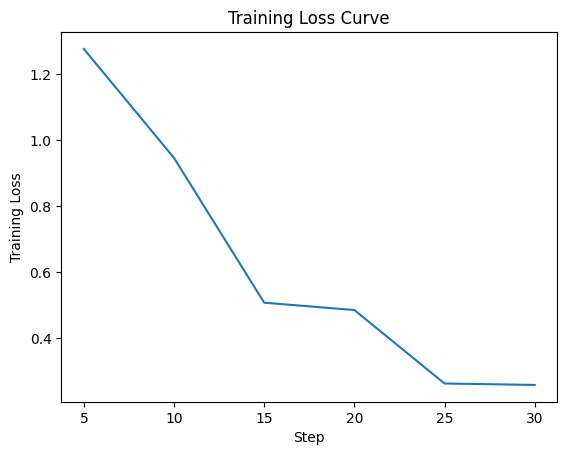


=== Final Metrics ===
train_runtime: 160.56
train_samples_per_second: 0.747
train_steps_per_second: 0.187
train_loss: 0.6230183720588685


In [ ]:
import matplotlib.pyplot as plt

# extract output from history
log_history = trainer.state.log_history

logs_df = pd.DataFrame(log_history)

print("=== Raw Log History ===")
print(logs_df.head())

# Filter steps with training loss
loss_df = logs_df[logs_df["loss"].notna()].copy()

print("\n=== Training Loss by Step ===")
print(loss_df[["step", "loss"]])

# loss curve
plt.figure()
plt.plot(loss_df["step"], loss_df["loss"])
plt.xlabel("Step")
plt.ylabel("Training Loss")
plt.title("Training Loss Curve")
plt.show()

# metrics
if "train_runtime" in logs_df.columns:
    final_metrics = logs_df.iloc[-1]
    print("\n=== Final Metrics ===")
    for key in final_metrics.index:
        if "train" in key or "runtime" in key:
            print(f"{key}: {final_metrics[key]}")

Evaluation (only on product not used in to produce training dataset)

In [ ]:
model.eval()

test_df = df_product.drop(train_df.index)

row = test_df.iloc[0]

prompt = prompt_v2(row)

review_test = generate_review(
    prompt,
    max_new_tokens=700,
    temperature=0.3,
    top_p=0.85
)

print(review_test)

Headline
A versatile and user-friendly Kindle Paperwhite with excellent screen quality.

Product summary
Users praise the lightweight and portable design of the Kindle Paperwhite, as well as its easy-to-use touchscreen interface. Some buyers express disappointment with the inability to enlarge fonts for PDF files and the unresponsive screen compared to tablets.

Key features
- Touchscreen interface: Allows users to navigate and read books without physical buttons.
- Backlight: Enhances readability in low-light conditions.
- Wifi capability: Enables users to download books directly from the Kindle Store.

Pros
- Intuitive touchscreen navigation
- Portable and lightweight design
- High-quality backlit display

Cons
- Inability to enlarge fonts for PDF files
- Unresponsive screen compared to tablets
- Limited improvement in font size for PDFs

Final assessment
The Kindle Paperwhite offers a user-friendly reading experience with its touchscreen interface and high-quality backlit display. H

INTERPRETATION

The updated version demonstrates stronger structural consistency and improved separation between positive and negative aspects, with fewer polarity errors and no quotation leakage. Overall, the model shows clearer alignment with the intended review format and more stable generalization across unseen products.

CREATE AND EXPORT REVIEWS

1. Imports
2. generate_product_review
3. parse_review
4. build_review_json
5. save_review_json
6. generate_batch_reviews
7. load_review_json
8. render_review_from_json

imports

In [ ]:
import os
import json
import re
from IPython.display import display, HTML

generate product review

In [ ]:
def generate_product_review(row):
    prompt = prompt_v2(row)

    review_text = generate_review(
        prompt,
        max_new_tokens=800,
        temperature=0.3,
        top_p=0.85
    )

    return review_text

parser

In [ ]:

def parse_review(review_text):

    sections = {
        "headline": "",
        "summary": "",
        "key_features": [],
        "pros": [],
        "cons": [],
        "final_assessment": ""
    }

    # Normalize end of paragraphs
    text = review_text.strip()

    # Split by section
    pattern = r"(Headline|Product summary|Key features|Pros|Cons|Final assessment)"
    parts = re.split(pattern, text)


    for i in range(1, len(parts), 2):
        section_name = parts[i].strip()
        section_content = parts[i+1].strip()

        if section_name == "Headline":
            sections["headline"] = section_content.split("\n")[0].strip()

        elif section_name == "Product summary":
            sections["summary"] = section_content.strip()

        elif section_name == "Key features":
            sections["key_features"] = re.findall(r"- (.+)", section_content)

        elif section_name == "Pros":
            sections["pros"] = re.findall(r"- (.+)", section_content)

        elif section_name == "Cons":
            sections["cons"] = re.findall(r"- (.+)", section_content)

        elif section_name == "Final assessment":
            sections["final_assessment"] = section_content.strip()

    return sections

build json

In [ ]:
def build_review_json(row, parsed_review):

    review_json = {
        "product_id": row["id"],
        "name": row["name"],
        "brand": row["brand"],
        "category": row["macro_category"],
        "score": round((row["avg_sentiment_intensity"] + 1) * 5, 1),
        "rank": int(row["rank_in_category"]),
        "image": row["imageURL"],
        "review": parsed_review
    }

    return review_json

Save json

In [ ]:
# save json
def save_review_json(review_json, index, output_folder="reviews_json"):


    os.makedirs(output_folder, exist_ok=True)

    # save review JSON using numeric filenames: 1.json, 2.json, etc.
    filename = os.path.join(output_folder, f"{index}.json")

    with open(filename, "w", encoding="utf-8") as f:
        json.dump(review_json, f, indent=4)

    print(f"Saved: {filename}")

generate + parse + save (single product)

In [ ]:
row = df_product.iloc[0]
index = df_product.index[0]

review_text = generate_product_review(row)
parsed = parse_review(review_text)
review_json = build_review_json(row, parsed)

save_review_json(review_json, index)

Saved: reviews_json/0.json


batch export

In [ ]:
def generate_batch_reviews(df_subset, output_folder="reviews_json"):

    for idx, (_, row) in enumerate(df_subset.iterrows(), start=1):

        review_text = generate_product_review(row)
        parsed = parse_review(review_text)
        review_json = build_review_json(row, parsed)

        save_review_json(review_json, idx, output_folder)

    print("Batch generation complete.")

"""
# Holdout only
holdout_df = df_product.drop(train_df.index)
generate_batch_reviews(holdout_df)

# Or all products
generate_batch_reviews(df_product)
"""
generate_batch_reviews(df_product.sample(n=20))

Saved: reviews_json/1.json
Saved: reviews_json/2.json
Saved: reviews_json/3.json
Saved: reviews_json/4.json
Saved: reviews_json/5.json
Saved: reviews_json/6.json
Saved: reviews_json/7.json
Saved: reviews_json/8.json
Saved: reviews_json/9.json
Saved: reviews_json/10.json
Saved: reviews_json/11.json
Saved: reviews_json/12.json
Saved: reviews_json/13.json
Saved: reviews_json/14.json
Saved: reviews_json/15.json
Saved: reviews_json/16.json
Saved: reviews_json/17.json
Saved: reviews_json/18.json
Saved: reviews_json/19.json
Saved: reviews_json/20.json
Batch generation complete.


RENDER

html

In [ ]:
def review_to_html(parsed, product_meta=None):
    """
    Clean single-column editorial layout.
    No duplicated sections.
    """

    # Metadata
    name = product_meta.get("name", "") if product_meta else ""
    brand = product_meta.get("brand", "") if product_meta else ""
    category = product_meta.get("category", "") if product_meta else ""
    score = product_meta.get("score", "") if product_meta else ""
    rank = product_meta.get("rank", "") if product_meta else ""
    image = product_meta.get("image", "") if product_meta else ""

    # Star conversion
    stars = ""
    if score != "":
        stars_count = int(round(float(score) / 2))
        stars = "★" * stars_count

    cons_items = parsed["cons"] if parsed["cons"] else ["None"]

    html = f"""
    <html>
    <head>
        <meta name="viewport" content="width=device-width, initial-scale=1.0">
        <style>

            body {{
                font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
                background: #f4f6f9;
                margin: 0;
                padding: 40px;
                color: #1f2937;
            }}

            .container {{
                max-width: 1000px;
                margin: auto;
                background: white;
                padding: 40px;
                border-radius: 14px;
                box-shadow: 0 12px 30px rgba(0,0,0,0.08);
            }}

            h1 {{
                font-size: 36px;
                margin-bottom: 30px;
            }}

            .top-block {{
                display: flex;
                gap: 40px;
                align-items: center;
                margin-bottom: 50px;
                flex-wrap: wrap;
            }}

            .product-image {{
                max-width: 420px;
                width: 100%;
                border-radius: 12px;
                box-shadow: 0 6px 18px rgba(0,0,0,0.1);
            }}

            .data-panel {{
                flex: 1;
            }}

            .score {{
                font-size: 56px;
                font-weight: 700;
                color: #2563eb;
            }}

            .stars {{
                color: #fbbf24;
                font-size: 26px;
                margin-top: 5px;
            }}

            .rank {{
                margin-top: 10px;
                font-weight: bold;
                font-size: 18px;
            }}

            .meta {{
                margin-top: 25px;
                line-height: 1.6;
            }}

            h2 {{
                margin-top: 40px;
                color: #2563eb;
                font-size: 24px;
            }}

            ul {{
                padding-left: 20px;
                margin-top: 10px;
            }}

            li {{
                margin-bottom: 8px;
            }}

            .final {{
                margin-top: 40px;
                background: #e0ecff;
                padding: 25px;
                border-radius: 10px;
            }}

            /* Mobile */
            @media (max-width: 768px) {{
                body {{
                    padding: 20px;
                }}
                .top-block {{
                    flex-direction: column;
                    align-items: flex-start;
                }}
                .score {{
                    font-size: 44px;
                }}
            }}

        </style>
    </head>

    <body>

        <div class="container">

            <h1>{name}</h1>

            <div class="top-block">

                <div>
                    {f'<img src="{image}" class="product-image"/>' if image else ""}
                </div>

                <div class="data-panel">
                    <div class="score">{score}/10</div>
                    <div class="stars">{stars}</div>
                    <div class="rank">Ranked #{rank} in its category</div>

                    <div class="meta">
                        <p><strong>Brand:</strong> {brand}</p>
                        <p><strong>Category:</strong> {category}</p>
                    </div>
                </div>

            </div>

            <h2>{parsed['headline']}</h2>

            <p>{parsed['summary']}</p>

            <h2>Key Features</h2>
            <ul>
                {''.join(f"<li>{item}</li>" for item in parsed['key_features'])}
            </ul>

            <h2>Pros</h2>
            <ul>
                {''.join(f"<li>{item}</li>" for item in parsed['pros'])}
            </ul>

            <h2>Cons</h2>
            <ul>
                {''.join(f"<li>{item}</li>" for item in cons_items)}
            </ul>

            <div class="final">
                <h2>Final Assessment</h2>
                <p>{parsed['final_assessment']}</p>
            </div>

        </div>

    </body>
    </html>
    """

    return html

load review json

In [ ]:
def load_review_json(filepath):

    with open(filepath, "r", encoding="utf-8") as f:
        review_json = json.load(f)

    return review_json

render html from json

In [ ]:
def render_review_from_json(filepath):

    review_json = load_review_json(filepath)

    html = review_to_html(
        review_json["review"],
        {
            "name": review_json["name"],
            "brand": review_json["brand"],
            "category": review_json["category"],
            "score": review_json["score"],
            "rank": review_json["rank"],
            "image": review_json["image"]
        }
    )

    display(HTML(html))

render review by number

In [ ]:
def render_review_by_number(number, folder="reviews_json"):

    filepath = os.path.join(folder, f"{number}.json")

    review_json = load_review_json(filepath)

    html = review_to_html(
        review_json["review"],
        {
            "name": review_json["name"],
            "brand": review_json["brand"],
            "category": review_json["category"],
            "score": review_json["score"],
            "rank": review_json["rank"],
            "image": review_json.get("image", "")
        }
    )

    display(HTML(html))

call render review by number

In [ ]:
render_review_by_number(0)

call render review by name

In [ ]:
render_review_from_json("reviews_json/1.json")

export html to file

In [ ]:
def export_review_html(number, folder_json="reviews_json", folder_html="reviews_html"):
    """
    Load JSON by number and export as standalone HTML file.
    """

    os.makedirs(folder_html, exist_ok=True)

    # Load JSON
    json_path = os.path.join(folder_json, f"{number}.json")
    review_json = load_review_json(json_path)

    # Generate HTML
    html_content = review_to_html(
        review_json["review"],
        {
            "name": review_json["name"],
            "brand": review_json["brand"],
            "category": review_json["category"],
            "score": review_json["score"],
            "rank": review_json["rank"],
            "image": review_json.get("image", "")
        }
    )

    # Save HTML
    html_path = os.path.join(folder_html, f"{number}.html")

    with open(html_path, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"HTML exported to: {html_path}")

call export review by number

In [ ]:
export_review_html(1)

HTML exported to: reviews_html/1.html


export in batch

In [ ]:
def export_all_html(folder_json="reviews_json", folder_html="reviews_html"):

    os.makedirs(folder_html, exist_ok=True)

    files = sorted(os.listdir(folder_json), key=lambda x: int(x.split(".")[0]))

    for file in files:
        number = int(file.split(".")[0])
        export_review_html(number, folder_json, folder_html)

    print("All HTML files exported.")

In [ ]:
export_all_html()

HTML exported to: reviews_html/0.html
HTML exported to: reviews_html/1.html
HTML exported to: reviews_html/2.html
HTML exported to: reviews_html/3.html
HTML exported to: reviews_html/4.html
HTML exported to: reviews_html/5.html
HTML exported to: reviews_html/6.html
HTML exported to: reviews_html/7.html
HTML exported to: reviews_html/8.html
HTML exported to: reviews_html/9.html
HTML exported to: reviews_html/10.html
HTML exported to: reviews_html/11.html
HTML exported to: reviews_html/12.html
HTML exported to: reviews_html/13.html
HTML exported to: reviews_html/14.html
HTML exported to: reviews_html/15.html
HTML exported to: reviews_html/16.html
HTML exported to: reviews_html/17.html
HTML exported to: reviews_html/18.html
HTML exported to: reviews_html/19.html
HTML exported to: reviews_html/20.html
All HTML files exported.


build json

In [ ]:
# Select one product (for testing)
row = df_product.iloc[0]

# Build prompt
prompt = prompt_v2(row)

# Generate review using trained model
review_text = generate_review(
    prompt,
    max_new_tokens=700,
    temperature=0.3,
    top_p=0.85
)

print(review_text)

In [ ]:
parsed = parse_review(review_text)
parsed

html template

In [ ]:
html = review_to_html(parsed, {
    "name": row["name"],
    "brand": row["brand"],
    "category": row["macro_category"],
    "score": round(scale_score(row["avg_sentiment_intensity"]), 1),
    "rank": int(row["rank_in_category"])
})

from IPython.display import display, HTML
display(HTML(html))

In [ ]:
def render_review_html(review):

    stars = "★" * int(round(review["score"] / 2))  # scale 0-10

    features_html = "".join([f"<li>{f}</li>" for f in review["key_features"]])
    pros_html = "".join([f"<li>{p}</li>" for p in review["pros"]])
    cons_html = "".join([f"<li>{c}</li>" for c in review["cons"]])

    html = f"""
    <html>
    <head>
        <style>
            body {{
                font-family: Arial, sans-serif;
                margin: 40px;
                background-color: #f4f4f4;
            }}
            .container {{
                background: white;
                padding: 30px;
                border-radius: 10px;
                box-shadow: 0 4px 10px rgba(0,0,0,0.1);
            }}
            .header {{
                display: flex;
                justify-content: space-between;
                align-items: center;
            }}
            .score {{
                font-size: 28px;
                font-weight: bold;
                color: #1e88e5;
            }}
            .stars {{
                color: gold;
            }}
            .image {{
                max-width: 250px;
                margin-top: 20px;
            }}
            h2 {{
                margin-top: 30px;
            }}
            ul {{
                margin-left: 20px;
            }}
        </style>
    </head>
    <body>
        <div class="container">

            <div class="header">
                <div>
                    <h1>{review["name"]}</h1>
                    <p><strong>Brand:</strong> {review["brand"]}</p>
                    <p><strong>Category:</strong> {review["category"]}</p>
                    <p><strong>Rank:</strong> {review["rank"]}</p>
                </div>
                <div>
                    <div class="score">{review["score"]}/10</div>
                    <div class="stars">{stars}</div>
                </div>
            </div>

            {f'<img src="{review["image"]}" class="image"/>' if review["image"] else ""}

            <h2>{review["headline"]}</h2>

            <p>{review["summary"]}</p>

            <h2>Key Features</h2>
            <ul>{features_html}</ul>

            <h2>Pros</h2>
            <ul>{pros_html}</ul>

            <h2>Cons</h2>
            <ul>{cons_html}</ul>

        </div>
    </body>
    </html>
    """

    return html

In [ ]:
import json

json_output = json.dumps(parsed, indent=2)
print(json_output)

{
  "headline": "A versatile and expandable folder organizer with excellent value.",
  "summary": "Users praise the portability and functionality of this expandable folder organizer. Its sturdy construction and affordable price make it a popular choice for various projects.",
  "key_features": [
    "Expandable design: Allows for increased storage capacity.",
    "Portable: Easy to transport and use on the go.",
    "Sturdy construction: Durable enough for various projects."
  ],
  "pros": [
    "Expandable design caters to various storage needs.",
    "Portable and easy to transport.",
    "Affordable price offers good value."
  ],
  "cons": [
    "None mentioned in the excerpts."
  ],
  "final_assessment": ""
}


In [ ]:
def review_to_html(parsed, product_meta=None):
    """
    Convert parsed review dictionary into styled HTML.
    """

    # Optional metadata (brand, category, score, etc.)
    meta_html = ""
    if product_meta:
        meta_html = f"""
        <div class="meta">
            <p><strong>Brand:</strong> {product_meta.get('brand','')}</p>
            <p><strong>Category:</strong> {product_meta.get('category','')}</p>
            <p><strong>User score:</strong> {product_meta.get('score','')}</p>
            <p><strong>Rank in category:</strong> {product_meta.get('rank','')}</p>
        </div>
        """

    html = f"""
    <html>
    <head>
        <style>
            body {{ font-family: Arial, sans-serif; max-width: 800px; margin: auto; padding: 20px; }}
            h1 {{ border-bottom: 2px solid #ddd; padding-bottom: 5px; }}
            h2 {{ margin-top: 30px; }}
            ul {{ margin-top: 5px; }}
            .meta {{ background: #f5f5f5; padding: 10px; margin-bottom: 20px; }}
            .final {{ margin-top: 30px; font-style: italic; }}
        </style>
    </head>
    <body>

        <h1>{parsed['headline']}</h1>

        {meta_html}

        <h2>Product Summary</h2>
        <p>{parsed['summary']}</p>

        <h2>Key Features</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in parsed['key_features'])}
        </ul>

        <h2>Pros</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in parsed['pros'])}
        </ul>

        <h2>Cons</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in parsed['cons'])}
        </ul>

        <div class="final">
            <h2>Final Assessment</h2>
            <p>{parsed['final_assessment']}</p>
        </div>

    </body>
    </html>
    """

    return html

Generate one review and export


In [ ]:
def generate_review_html(row, filename="review.html"):

    prompt = prompt_v2(row)

    review_text = generate_review(
        prompt,
        max_new_tokens=600,
        temperature=0.3,
        top_p=0.85
    )

    parsed = parse_review(review_text)

    meta = {
        "brand": row["brand"],
        "category": row["macro_category"],
        "score": round((row["avg_sentiment_intensity"] + 1) * 5, 1),
        "rank": int(row["rank_in_category"])
    }

    html_content = review_to_html(parsed, meta)

    with open(filename, "w", encoding="utf-8") as f:
        f.write(html_content)

    print(f"Review exported to {filename}")

In [ ]:
generate_review_html(df_product.iloc[0], "test_review.html")

Review exported to test_review.html


In [ ]:
def review_to_html(parsed, product_meta=None):
    """
    Convert parsed review dictionary into styled HTML.
    """

    # Prepare score block
    score_html = ""
    meta_block = ""

    if product_meta:
        score = product_meta.get("score", "")
        rank = product_meta.get("rank", "")
        brand = product_meta.get("brand", "")
        category = product_meta.get("category", "")

        # Convert 0–10 scale into 5-star system
        if score != "":
            stars_count = int(round(float(score) / 2))
            stars = "★" * stars_count
        else:
            stars = ""

        score_html = f"""
        <div class="score-box">
            <div class="score-value">{score}/10</div>
            <div class="stars">{stars}</div>
            <div class="rank">Ranked #{rank} in category</div>
        </div>
        """

        meta_block = f"""
        <div class="meta">
            <p><strong>Brand:</strong> {brand}</p>
            <p><strong>Category:</strong> {category}</p>
        </div>
        """

    # Handle empty cons
    cons_items = parsed["cons"] if parsed["cons"] else ["None"]

    html = f"""
    <html>
    <head>
        <style>
            body {{
                font-family: Arial, sans-serif;
                max-width: 900px;
                margin: auto;
                padding: 30px;
            }}

            h1 {{
                border-bottom: 2px solid #ddd;
                padding-bottom: 10px;
            }}

            h2 {{
                margin-top: 35px;
            }}

            ul {{
                margin-top: 5px;
            }}

            .score-box {{
                margin-top: 20px;
                margin-bottom: 20px;
            }}

            .score-value {{
                font-size: 48px;
                font-weight: bold;
                color: #1e88e5;
            }}

            .stars {{
                color: gold;
                font-size: 28px;
                margin-top: 5px;
            }}

            .rank {{
                margin-top: 5px;
                font-size: 16px;
                color: #555;
            }}

            .meta {{
                background: #f5f5f5;
                padding: 15px;
                margin-bottom: 25px;
                border-radius: 6px;
            }}

            .final {{
                margin-top: 35px;
                font-style: normal;   /* Removed italic */
            }}

        </style>
    </head>
    <body>

        <h1>{parsed['headline']}</h1>

        {score_html}

        {meta_block}

        <h2>Product Summary</h2>
        <p>{parsed['summary']}</p>

        <h2>Key Features</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in parsed['key_features'])}
        </ul>

        <h2>Pros</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in parsed['pros'])}
        </ul>

        <h2>Cons</h2>
        <ul>
            {''.join(f"<li>{item}</li>" for item in cons_items)}
        </ul>

        <div class="final">
            <h2>Final Assessment</h2>
            <p>{parsed['final_assessment']}</p>
        </div>

    </body>
    </html>
    """

    return html

In [ ]:
review_dict = {
    "name": row["name"],
    "brand": row["brand"],
    "category": row["macro_category"],
    "rank": int(row["rank_in_category"]),
    "score": round((row["avg_sentiment_intensity"] + 1) * 5, 1),
    "image": row.get("image_url", ""),  # cambia si tu columna tiene otro nombre
    "headline": parsed["headline"],
    "summary": parsed["summary"],
    "key_features": parsed["key_features"],
    "pros": parsed["pros"],
    "cons": parsed["cons"]
}

In [ ]:
html_content = render_review_html(review_dict)

with open("test_render.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("HTML exported as test_render.html")

HTML exported as test_render.html


Export test

In [ ]:
row = df_product.iloc[0]

prompt = prompt_v2(row)
generated = generate_review(prompt, max_new_tokens=700, temperature=0.4)

review_json = build_review_json(row, generated)
html = render_review_html(review_json)

with open("review_test.html", "w", encoding="utf-8") as f:
    f.write(html)

print("Saved review_test.html")

NameError: name 'parse_review_output' is not defined

Export holdout

In [ ]:
import os

os.makedirs("reviews_holdout", exist_ok=True)

test_df = df_product.drop(train_df.index)

for idx, row in test_df.iterrows():

    prompt = prompt_v2(row)
    generated = generate_review(prompt, max_new_tokens=700, temperature=0.4)

    review_json = build_review_json(row, generated)
    html = render_review_html(review_json)

    filename = f"reviews_holdout/{row['id']}.html"

    with open(filename, "w", encoding="utf-8") as f:
        f.write(html)

print("Holdout export complete.")

Export all

In [ ]:
os.makedirs("reviews_all", exist_ok=True)

for idx, row in df_product.iterrows():

    prompt = prompt_v2(row)
    generated = generate_review(prompt, max_new_tokens=700, temperature=0.4)

    review_json = build_review_json(row, generated)
    html = render_review_html(review_json)

    filename = f"reviews_all/{row['id']}.html"

    with open(filename, "w", encoding="utf-8") as f:
        f.write(html)

print("All reviews exported.")

In [ ]:
def build_review_json(row, generated_text):

    parsed = parse_review_output(generated_text)

    return {
        "name": row["name"],
        "brand": row["brand"],
        "category": row["macro_category"],
        "score": round((row["avg_sentiment_intensity"] + 1) * 5, 1),
        "rank": int(row["rank_in_category"]),
        "image": row.get("image_url", ""),  # ajusta nombre si es distinto
        "headline": parsed["headline"],
        "summary": parsed["summary"],
        "key_features": parsed["key_features"],
        "pros": parsed["pros"],
        "cons": parsed["cons"]
    }